In [2]:
%pip install -q wfdb medmnist

import os
import shutil
import tarfile
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

WORKING_DIR = "/kaggle/working/data"
os.makedirs(f"{WORKING_DIR}/pneumonia", exist_ok=True)
os.makedirs(f"{WORKING_DIR}/chestmnist", exist_ok=True)
os.makedirs(f"{WORKING_DIR}/mit_bih", exist_ok=True)

status = {"pneumonia": False, "chestmnist": False, "mit_bih": False}

for root, dirs, files in os.walk("/kaggle/input"):
    if "pneumoniamnist.npz" in files and not status["pneumonia"]:
        src = os.path.join(root, "pneumoniamnist.npz")
        shutil.copy(src, f"{WORKING_DIR}/pneumonia/pneumoniamnist.npz")
        status["pneumonia"] = True
        print(f"Copied PneumoniaMNIST from: {root}")

    if "chestmnist.npz" in files and not status["chestmnist"]:
        src = os.path.join(root, "chestmnist.npz")
        shutil.copy(src, f"{WORKING_DIR}/pneumonia/chestmnist.npz")
        status["chestmnist"] = True
        print(f"Copied chestmnist from: {root}")

    if "100.dat" in files and not status["mit_bih"]:
        for item in os.listdir(root):
            s = os.path.join(root, item)
            d = os.path.join(f"{WORKING_DIR}/mit_bih", item)
            if os.path.isdir(s):
                shutil.copytree(s, d, dirs_exist_ok=True)
            else:
                shutil.copy2(s, d)
        status["mit_bih"] = True
        print(f"Copied MIT-BIH from: {root}")

print("\nSetup Summary")
for dataset, success in status.items():
    print(f"{dataset.upper():<12} : {'SUCCESS' if success else 'FAILED (Not Found)'}")

print("\nContents of WORKING_DIR")
for item in sorted(os.listdir(WORKING_DIR)):
    print(f"- {item}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Copied PneumoniaMNIST from: /kaggle/input/datasets/sajeebhasan/fl-data
Copied chestmnist from: /kaggle/input/datasets/sajeebhasan/fl-data
Copied MIT-BIH from: /kaggle/input/datasets/sajeebhasan/fl-data/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0

Setup Summary
PNEUMONIA    : SUCCESS
CHESTMNIST   : SUCCESS
MIT_BIH      : SUCCESS

Contents of WORKING_DIR
- chestmnist
- mit_bih
- pneumonia


In [4]:
# Cell 2: Load PneumoniaMNIST and set core configuration

import numpy as np
import torch
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

NUM_CLIENTS = 5
ALPHA = 0.5
FEATURE_DIM = 64
N_GMM_COMPONENTS = 3
CLIP_NORM = 1.0
EPSILON = 0.2

PLOT_SMOOTH_ALPHA = 0.20
RAW_CURVE_ALPHA = 0.22

WORKING_DIR = "/kaggle/working/data"

pneu_data = np.load(f"{WORKING_DIR}/pneumonia/pneumoniamnist.npz")

X_train_raw = pneu_data["train_images"]
y_train_raw = pneu_data["train_labels"].squeeze().astype(np.int64)

X_val_raw = pneu_data["val_images"]
y_val_raw = pneu_data["val_labels"].squeeze().astype(np.int64)

X_test_raw = pneu_data["test_images"]
y_test_raw = pneu_data["test_labels"].squeeze().astype(np.int64)

print("summary")
print(f"  Train : {len(X_train_raw):>5} samples | normal={np.sum(y_train_raw == 0):>5} | pneumonia={np.sum(y_train_raw == 1):>5}")
print(f"  Val   : {len(X_val_raw):>5} samples | normal={np.sum(y_val_raw == 0):>5} | pneumonia={np.sum(y_val_raw == 1):>5}")
print(f"  Test  : {len(X_test_raw):>5} samples | normal={np.sum(y_test_raw == 0):>5} | pneumonia={np.sum(y_test_raw == 1):>5}")

def smooth_curve(values, alpha=PLOT_SMOOTH_ALPHA):
    values = np.asarray(values, dtype=np.float32)
    if values.size == 0:
        return values

    smoothed = np.empty_like(values, dtype=np.float32)
    smoothed[0] = values[0]

    for idx in range(1, len(values)):
        smoothed[idx] = alpha * values[idx] + (1.0 - alpha) * smoothed[idx - 1]

    return smoothed

def plot_raw_and_smooth(ax, values, label, color, alpha=PLOT_SMOOTH_ALPHA, raw_alpha=RAW_CURVE_ALPHA):
    values = np.asarray(values, dtype=np.float32)
    if values.size == 0:
        return

    epochs = np.arange(1, len(values) + 1)
    ax.plot(epochs, values, color=color, alpha=raw_alpha, linewidth=1.0, label="_nolegend_")
    ax.plot(epochs, smooth_curve(values, alpha=alpha), color=color, linewidth=2.5, label=f"{label} (EMA)")

summary
  Train :  4708 samples | normal= 1214 | pneumonia= 3494
  Val   :   524 samples | normal=  135 | pneumonia=  389
  Test  :   624 samples | normal=  234 | pneumonia=  390


Stable non-IID partition on the training split
  Hospital 0: Total=1356 | Normal= 161, Pneumonia=1195
  Hospital 1: Total=1104 | Normal=   8, Pneumonia=1096
  Hospital 2: Total= 593 | Normal= 172, Pneumonia= 421
  Hospital 3: Total= 366 | Normal= 294, Pneumonia=  72
  Hospital 4: Total=1289 | Normal= 579, Pneumonia= 710

Total assigned: 4708 / 4708


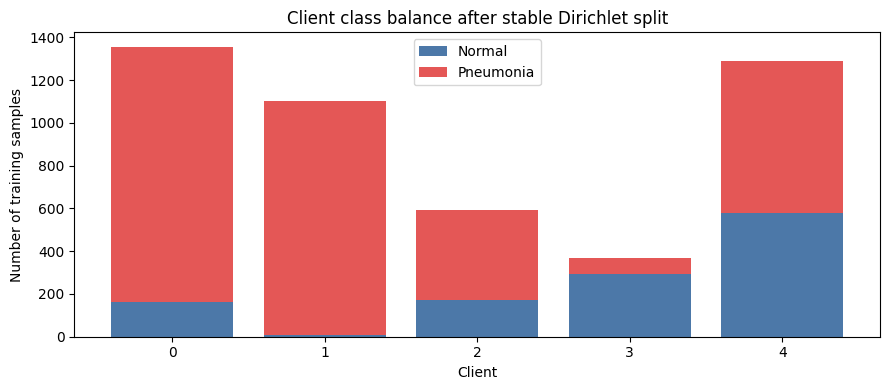

In [6]:
# Cell 3: Build a stable non-IID client split and inspect client label balance

import matplotlib.pyplot as plt

def stable_dirichlet_split(
    labels,
    num_clients,
    alpha,
    num_classes,
    min_total=48,
    min_per_class=8,
    max_retries=2000,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)

    for _ in range(max_retries):
        client_indices = {i: [] for i in range(num_clients)}

        for cls in range(num_classes):
            idx_c = np.where(labels == cls)[0]
            rng.shuffle(idx_c)

            proportions = rng.dirichlet(np.repeat(alpha, num_clients))
            cut_points = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
            splits = np.split(idx_c, cut_points)

            for client_id, split_idx in enumerate(splits):
                client_indices[client_id].extend(split_idx.tolist())

        valid = True
        for client_id in range(num_clients):
            idx = np.array(client_indices[client_id], dtype=np.int64)
            if len(idx) < min_total:
                valid = False
                break

            counts = np.bincount(labels[idx], minlength=num_classes)
            if (counts < min_per_class).any():
                valid = False
                break

        if valid:
            return {k: np.array(v, dtype=np.int64) for k, v in client_indices.items()}

    raise RuntimeError(
    )

client_splits = stable_dirichlet_split(
    labels=y_train_raw,
    num_clients=NUM_CLIENTS,
    alpha=ALPHA,
    num_classes=2,
    min_total=48,
    min_per_class=8,
)

print("Stable non-IID partition on the training split")
total_assigned = 0
client_hist = np.zeros((NUM_CLIENTS, 2), dtype=np.int64)

for cid, indices in client_splits.items():
    lbl = y_train_raw[indices]
    cc = np.bincount(lbl, minlength=2)
    client_hist[cid] = cc
    total_assigned += len(indices)
    print(f"  Hospital {cid}: Total={len(indices):>4} | Normal={cc[0]:>4}, Pneumonia={cc[1]:>4}")

assert total_assigned == len(y_train_raw), "Some training samples were not assigned!"
print(f"\nTotal assigned: {total_assigned} / {len(y_train_raw)}")

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(NUM_CLIENTS)

ax.bar(np.arange(NUM_CLIENTS), client_hist[:, 0], bottom=bottom, color="#4C78A8", label="Normal")
bottom += client_hist[:, 0]
ax.bar(np.arange(NUM_CLIENTS), client_hist[:, 1], bottom=bottom, color="#E45756", label="Pneumonia")

ax.set_title("Client class balance after stable Dirichlet split")
ax.set_xlabel("Client")
ax.set_ylabel("Number of training samples")
ax.set_xticks(np.arange(NUM_CLIENTS))
ax.legend()
plt.tight_layout()
plt.show()

Device      : cuda
Visible GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 128MB/s] 


Loaded pretrained DenseNet121 weights.


Train backbone features:   0%|          | 0/37 [00:00<?, ?it/s]

Val backbone features:   0%|          | 0/5 [00:00<?, ?it/s]

Test backbone features:   0%|          | 0/5 [00:00<?, ?it/s]

Backbone feature shape: (4708, 1024)
Compressed feature shape : (4708, 128)
PCA explained variance   : 0.8341


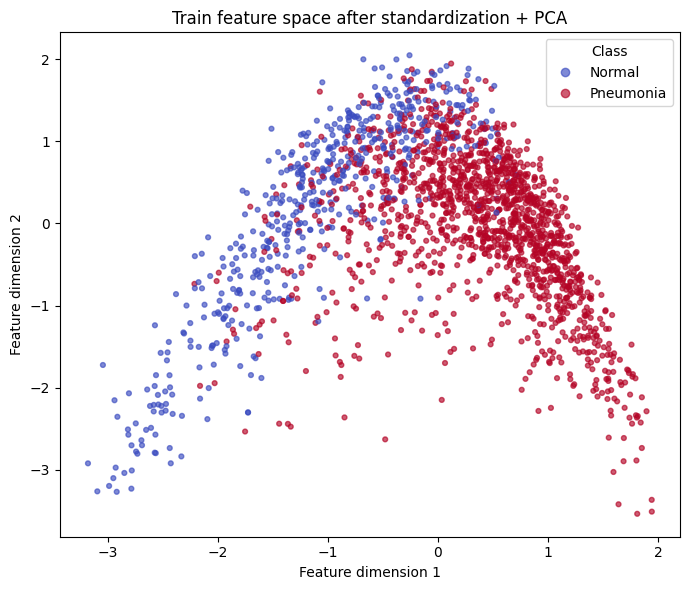

In [7]:
# Cell 4: Extract frozen DenseNet features and compress them with standardization + PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

FEATURE_DIM = 128
CLIP_NORM = 6.0
EPSILON = 1.0
N_GMM_COMPONENTS = 4
MIN_SAMPLES_PER_CLASS = max(2 * N_GMM_COMPONENTS, 16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()

print(f"Device      : {device}")
print(f"Visible GPUs: {num_gpus}")
if num_gpus > 0:
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

class MedicalVisionExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        try:
            backbone = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
            print("Loaded pretrained DenseNet121 weights.")
        except Exception as exc:
            print(f"Could not load pretrained weights, falling back to random init: {exc}")
            backbone = models.densenet121(weights=None)

        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        for param in self.features.parameters():
            param.requires_grad = False

    def forward(self, x):
        if x.ndim == 3:
            x = x.unsqueeze(1)

        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)

        if x.shape[-1] < 224:
            x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)

        x = self.features(x)
        x = F.relu(x, inplace=False)
        x = self.pool(x).flatten(1)
        return x

def images_to_tensor(images):
    return torch.from_numpy(images).float().div(255.0).unsqueeze(1)

@torch.no_grad()
def extract_backbone_features(images, batch_size=128, desc="Extracting backbone features"):
    image_tensor = images_to_tensor(images)
    chunks = []

    for start in tqdm(range(0, len(image_tensor), batch_size), desc=desc):
        batch = image_tensor[start:start + batch_size].to(device, non_blocking=True)
        feats = feature_extractor(batch).cpu().numpy().astype(np.float32)
        chunks.append(feats)

    return np.vstack(chunks)

feature_extractor = MedicalVisionExtractor()

if num_gpus > 1:
    feature_extractor = nn.DataParallel(feature_extractor)

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

train_backbone_features = extract_backbone_features(X_train_raw, desc="Train backbone features")
val_backbone_features = extract_backbone_features(X_val_raw, desc="Val backbone features")
test_backbone_features = extract_backbone_features(X_test_raw, desc="Test backbone features")

print(f"Backbone feature shape: {train_backbone_features.shape}")

feature_scaler = StandardScaler()
train_scaled = feature_scaler.fit_transform(train_backbone_features)
val_scaled = feature_scaler.transform(val_backbone_features)
test_scaled = feature_scaler.transform(test_backbone_features)

feature_pca = PCA(n_components=FEATURE_DIM, whiten=True, random_state=SEED)
X_train_features = feature_pca.fit_transform(train_scaled).astype(np.float32)
X_val_features = feature_pca.transform(val_scaled).astype(np.float32)
X_test_features = feature_pca.transform(test_scaled).astype(np.float32)

print(f"Compressed feature shape : {X_train_features.shape}")
print(f"PCA explained variance   : {feature_pca.explained_variance_ratio_.sum():.4f}")

sample_size = min(2000, len(X_train_features))
sample_idx = np.random.choice(len(X_train_features), size=sample_size, replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    X_train_features[sample_idx, 0],
    X_train_features[sample_idx, 1],
    c=y_train_raw[sample_idx],
    cmap="coolwarm",
    s=12,
    alpha=0.65,
)
legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, ["Normal", "Pneumonia"], title="Class")
ax.set_title("Train feature space after standardization + PCA")
ax.set_xlabel("Feature dimension 1")
ax.set_ylabel("Feature dimension 2")
plt.tight_layout()
plt.show()

Debiased feature norm summary
  mean   : 10.7863
  std    : 3.3656
  median : 9.9190
  p90    : 15.1856
  p95    : 17.5796
  p97.5  : 19.7809
  p99    : 22.1515
  max    : 47.1648

Updated CLIP_NORM = 19.7809


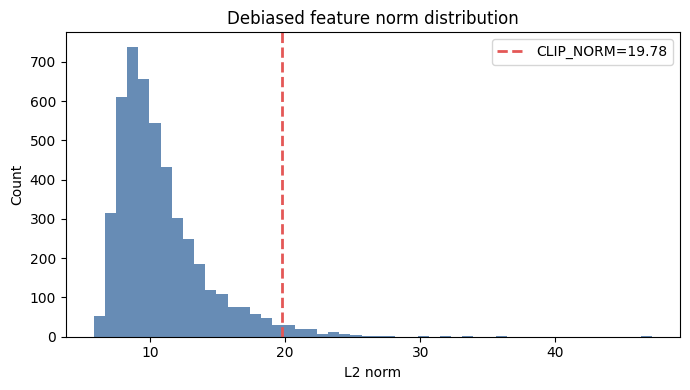

Rebuilding client payloads with calibrated clipping
Hospital 0: total=1356 | bias_norm=0.3614 | clipped_fraction=0.013
  Class 0 (normal): n= 161 | components=4
  Class 1 (pneumonia): n=1195 | components=4
Hospital 1: total=1104 | bias_norm=0.5347 | clipped_fraction=0.021
  Class 0 (normal): n=   8 | components=1
  Class 1 (pneumonia): n=1096 | components=4
Hospital 2: total= 593 | bias_norm=0.4401 | clipped_fraction=0.022
  Class 0 (normal): n= 172 | components=4
  Class 1 (pneumonia): n= 421 | components=4
Hospital 3: total= 366 | bias_norm=1.2001 | clipped_fraction=0.052
  Class 0 (normal): n= 294 | components=4
  Class 1 (pneumonia): n=  72 | components=4
Hospital 4: total=1289 | bias_norm=0.4691 | clipped_fraction=0.035
  Class 0 (normal): n= 579 | components=4
  Class 1 (pneumonia): n= 710 | components=4

Replay-feature clients saved : 5
Total replay features stored : 4708
Expected replay features     : 4708


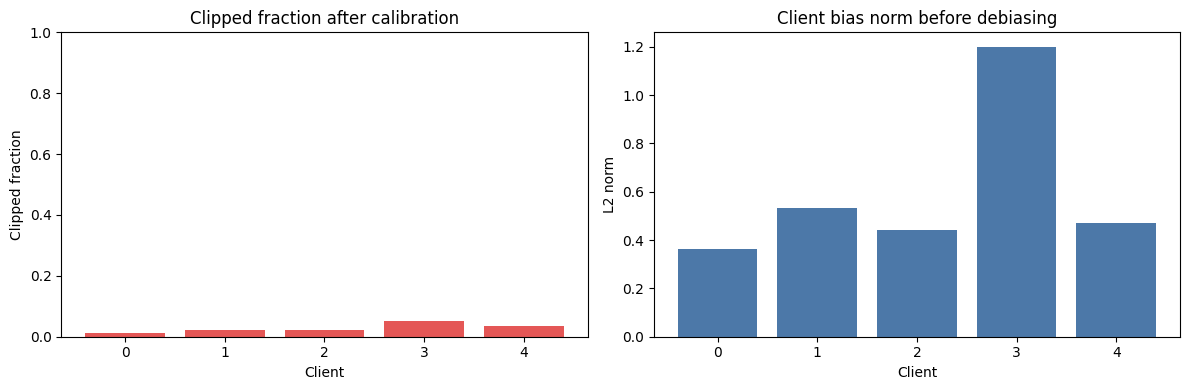

In [8]:
# Cell 5: Debias client features, calibrate clipping, and build private per-class GMM payloads

from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

class_names = {0: "normal", 1: "pneumonia"}
rng = np.random.default_rng(SEED)

def apply_dbe(features):
    local_bias = features.mean(axis=0).astype(np.float32)
    debiased_features = (features - local_bias).astype(np.float32)
    return debiased_features, local_bias

def clip_features(features, clip_norm=None):
    clip_norm = CLIP_NORM if clip_norm is None else clip_norm
    norms = np.linalg.norm(features, axis=1, keepdims=True)
    scales = np.minimum(1.0, clip_norm / (norms + 1e-8))
    return (features * scales).astype(np.float32)

def clipped_fraction(features, clip_norm=None):
    clip_norm = CLIP_NORM if clip_norm is None else clip_norm
    norms = np.linalg.norm(features, axis=1)
    return float(np.mean(norms > clip_norm))

def fit_private_gmm(features, n_components=None, epsilon=None, clip_norm=None):
    n_components = N_GMM_COMPONENTS if n_components is None else n_components
    epsilon = EPSILON if epsilon is None else epsilon
    clip_norm = CLIP_NORM if clip_norm is None else clip_norm

    clipped = clip_features(features, clip_norm)
    effective_components = max(1, min(n_components, len(clipped) // 12))
    if len(clipped) < 12:
        effective_components = 1

    gmm = GaussianMixture(
        n_components=effective_components,
        covariance_type="diag",
        reg_covar=5e-4,
        n_init=5,
        max_iter=300,
        random_state=SEED,
    )
    gmm.fit(clipped)

    means = gmm.means_.astype(np.float32)
    covs = gmm.covariances_.astype(np.float32)
    weights = gmm.weights_.astype(np.float32)

    if np.isfinite(epsilon) and epsilon > 0:
        noise_scale = clip_norm / epsilon
        means = means + rng.normal(0.0, noise_scale * 0.02, size=means.shape).astype(np.float32)
        covs = covs + rng.normal(0.0, noise_scale * 0.01, size=covs.shape).astype(np.float32)
        covs = np.clip(covs, 1e-5, None)

    order = np.argsort(np.linalg.norm(means, axis=1))
    means = means[order]
    covs = covs[order]
    weights = weights[order]
    weights = weights / weights.sum()

    return means, covs, weights

all_debiased_features = []
for client_id, indices in client_splits.items():
    local_features = X_train_features[indices]
    debiased_features, _ = apply_dbe(local_features)
    all_debiased_features.append(debiased_features)

all_debiased_features = np.vstack(all_debiased_features).astype(np.float32)
all_norms = np.linalg.norm(all_debiased_features, axis=1)

print("Debiased feature norm summary")
print(f"  mean   : {all_norms.mean():.4f}")
print(f"  std    : {all_norms.std():.4f}")
print(f"  median : {np.median(all_norms):.4f}")
print(f"  p90    : {np.quantile(all_norms, 0.90):.4f}")
print(f"  p95    : {np.quantile(all_norms, 0.95):.4f}")
print(f"  p97.5  : {np.quantile(all_norms, 0.975):.4f}")
print(f"  p99    : {np.quantile(all_norms, 0.99):.4f}")
print(f"  max    : {all_norms.max():.4f}")

CLIP_NORM = float(np.quantile(all_norms, 0.975))
print(f"\nUpdated CLIP_NORM = {CLIP_NORM:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(all_norms, bins=50, color="#4C78A8", alpha=0.85)
ax.axvline(CLIP_NORM, color="#E45756", linestyle="--", linewidth=2, label=f"CLIP_NORM={CLIP_NORM:.2f}")
ax.set_title("Debiased feature norm distribution")
ax.set_xlabel("L2 norm")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

client_payloads = {}
client_real_features = {}
client_stats = []

print("Rebuilding client payloads with calibrated clipping")

for client_id, indices in client_splits.items():
    local_features = X_train_features[indices]
    local_labels = y_train_raw[indices].astype(np.int64)

    debiased_features, local_bias = apply_dbe(local_features)
    bias_norm = float(np.linalg.norm(local_bias))
    clip_frac = clipped_fraction(debiased_features, CLIP_NORM)

    client_payload = {
        "bias": local_bias,
        "models": {},
        "n_samples": {},
    }

    print(
        f"Hospital {client_id}: total={len(indices):>4} | "
        f"bias_norm={bias_norm:.4f} | clipped_fraction={clip_frac:.3f}"
    )

    for class_label in [0, 1]:
        class_features = debiased_features[local_labels == class_label].astype(np.float32)
        n_cls = len(class_features)
        client_payload["n_samples"][class_label] = int(n_cls)

        if n_cls >= max(8, 2 * N_GMM_COMPONENTS):
            dp_means, dp_covs, dp_weights = fit_private_gmm(
                class_features,
                n_components=N_GMM_COMPONENTS,
                epsilon=EPSILON,
                clip_norm=CLIP_NORM,
            )
            client_payload["models"][class_label] = {
                "means": dp_means,
                "covs": dp_covs,
                "weights": dp_weights,
            }
            print(
                f"  Class {class_label} ({class_names[class_label]}): "
                f"n={n_cls:>4} | components={dp_means.shape[0]}"
            )
        else:
            print(
                f"  Class {class_label} ({class_names[class_label]}): "
                f"n={n_cls:>4} | skipped"
            )

    client_payloads[client_id] = client_payload
    client_real_features[client_id] = {
        "features": debiased_features.astype(np.float32),
        "labels": local_labels.astype(np.int64),
    }

    client_stats.append(
        {
            "client_id": client_id,
            "clip_fraction": clip_frac,
            "bias_norm": bias_norm,
        }
    )

total_replay = sum(len(v["labels"]) for v in client_real_features.values())
print(f"\nReplay-feature clients saved : {len(client_real_features)}")
print(f"Total replay features stored : {total_replay}")
print(f"Expected replay features     : {len(y_train_raw)}")

assert len(client_real_features) == NUM_CLIENTS, "Not all clients were saved."
assert total_replay == len(y_train_raw), "Replay feature storage is incomplete."

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(
    [row["client_id"] for row in client_stats],
    [row["clip_fraction"] for row in client_stats],
    color="#E45756",
)
axes[0].set_title("Clipped fraction after calibration")
axes[0].set_xlabel("Client")
axes[0].set_ylabel("Clipped fraction")
axes[0].set_ylim(0.0, 1.0)

axes[1].bar(
    [row["client_id"] for row in client_stats],
    [row["bias_norm"] for row in client_stats],
    color="#4C78A8",
)
axes[1].set_title("Client bias norm before debiasing")
axes[1].set_xlabel("Client")
axes[1].set_ylabel("L2 norm")

plt.tight_layout()
plt.show()

In [9]:
# Cell 6: Cluster-side aggregation helpers

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.optimize import linear_sum_assignment
    HAVE_HUNGARIAN = True
except Exception:
    HAVE_HUNGARIAN = False
    print("scipy.optimize.linear_sum_assignment not available, using greedy matching fallback.")

def match_components(local_means, ref_means):
    cost = np.linalg.norm(local_means[:, None, :] - ref_means[None, :, :], axis=2)

    if HAVE_HUNGARIAN:
        row_ind, col_ind = linear_sum_assignment(cost)
        matches = list(zip(row_ind.tolist(), col_ind.tolist()))
    else:
        matches = []
        used_cols = set()
        row_order = np.argsort(cost.min(axis=1))

        for row in row_order:
            available = [col for col in range(cost.shape[1]) if col not in used_cols]
            if not available:
                break
            best_col = min(available, key=lambda col: cost[row, col])
            matches.append((int(row), int(best_col)))
            used_cols.add(int(best_col))

    return matches, cost

def aggregate_biases(payloads):
    total_n = sum(sum(payload["n_samples"].values()) for payload in payloads.values())
    assert total_n > 0, "No samples found for bias aggregation."

    agg_bias = None
    for client_id, payload in payloads.items():
        client_n = sum(payload["n_samples"].values())
        weight = client_n / total_n
        client_bias = payload["bias"].astype(np.float32)

        if agg_bias is None:
            agg_bias = weight * client_bias
        else:
            agg_bias += weight * client_bias

    return agg_bias.astype(np.float32)

def aggregate_class_gmms(payloads, target_class):
    participating = []
    for client_id, payload in payloads.items():
        if target_class in payload["models"] and payload["n_samples"].get(target_class, 0) > 0:
            participating.append(client_id)

    if not participating:
        return None

    reference_client = max(
        participating,
        key=lambda cid: (
            payloads[cid]["models"][target_class]["means"].shape[0],
            payloads[cid]["n_samples"][target_class],
        ),
    )

    ref_model = payloads[reference_client]["models"][target_class]
    ref_means = ref_model["means"].astype(np.float32)
    ref_covs = ref_model["covs"].astype(np.float32)
    target_k = ref_means.shape[0]
    feature_dim = ref_means.shape[1]

    total_class_samples = sum(payloads[cid]["n_samples"][target_class] for cid in participating)

    weight_mass = np.zeros(target_k, dtype=np.float64)
    mean_numer = np.zeros((target_k, feature_dim), dtype=np.float64)
    cov_numer = np.zeros((target_k, feature_dim), dtype=np.float64)
    contributor_count = np.zeros(target_k, dtype=np.int64)

    for client_id in participating:
        local_model = payloads[client_id]["models"][target_class]
        local_means = local_model["means"].astype(np.float32)
        local_covs = local_model["covs"].astype(np.float32)
        local_weights = local_model["weights"].astype(np.float32)
        local_n = payloads[client_id]["n_samples"][target_class]

        matches, _ = match_components(local_means, ref_means)

        for local_idx, global_idx in matches:
            mass = float(local_n) * float(local_weights[local_idx])
            weight_mass[global_idx] += mass
            mean_numer[global_idx] += mass * local_means[local_idx]
            cov_numer[global_idx] += mass * local_covs[local_idx]

            if mass > 0:
                contributor_count[global_idx] += 1

    global_means = np.zeros_like(ref_means, dtype=np.float32)
    global_covs = np.zeros_like(ref_covs, dtype=np.float32)

    for k in range(target_k):
        if weight_mass[k] > 0:
            global_means[k] = (mean_numer[k] / weight_mass[k]).astype(np.float32)
            global_covs[k] = np.clip((cov_numer[k] / weight_mass[k]).astype(np.float32), 1e-5, None)
        else:
            global_means[k] = ref_means[k]
            global_covs[k] = np.clip(ref_covs[k], 1e-5, None)

    global_weights = (weight_mass / max(weight_mass.sum(), 1e-12)).astype(np.float32)

    return {
        "means": global_means,
        "covs": global_covs,
        "weights": global_weights,
        "reference_client": reference_client,
        "contributors": contributor_count,
        "total_class_samples": int(total_class_samples),
    }

Aligned aggregation of client payloads
cluster_bias shape: (128,)
cluster_bias norm : 0.0000


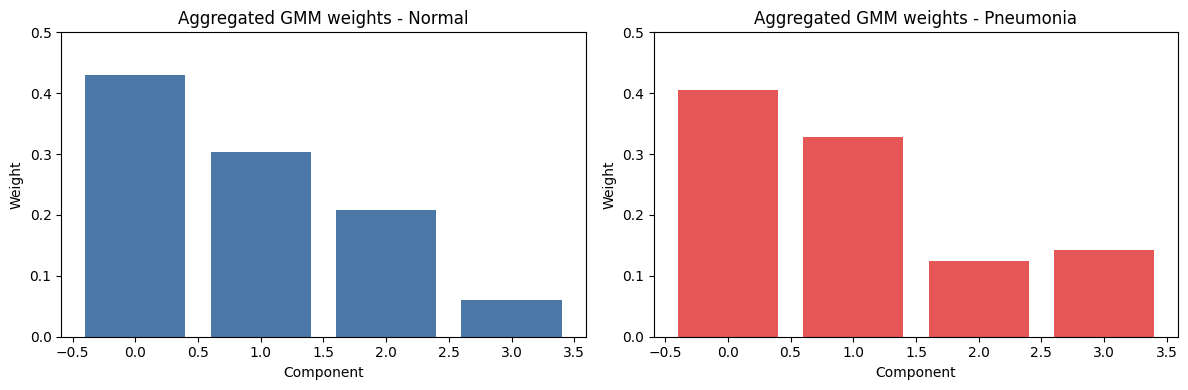

In [10]:
# Cell 7: Aggregate client payloads into cluster-level class distributions

print("Aligned aggregation of client payloads")

cluster_payload = {
    0: aggregate_class_gmms(client_payloads, target_class=0),
    1: aggregate_class_gmms(client_payloads, target_class=1),
}

cluster_bias = aggregate_biases(client_payloads)
print(f"cluster_bias shape: {cluster_bias.shape}")
print(f"cluster_bias norm : {np.linalg.norm(cluster_bias):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, ax in zip([0, 1], axes):
    if cluster_payload[cls] is None:
        ax.set_title(f"{class_names[cls].title()} - no payload")
        ax.axis("off")
        continue

    weights = cluster_payload[cls]["weights"]
    ax.bar(np.arange(len(weights)), weights, color="#4C78A8" if cls == 0 else "#E45756")
    ax.set_title(f"Aggregated GMM weights - {class_names[cls].title()}")
    ax.set_xlabel("Component")
    ax.set_ylabel("Weight")
    ax.set_ylim(0.0, max(0.5, float(weights.max()) + 0.05))

plt.tight_layout()
plt.show()

In [11]:
# Cell 8: Build the diffusion training set from aggregated GMMs + replay features

import copy
import math

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

class_names = {0: "normal", 1: "pneumonia"}

global_models = {}
for cls in [0, 1]:
    assert cluster_payload[cls] is not None, f"Missing aggregated payload for class {cls}"
    global_models[cls] = {
        "means": cluster_payload[cls]["means"].astype(np.float32),
        "covs": cluster_payload[cls]["covs"].astype(np.float32),
        "weights": cluster_payload[cls]["weights"].astype(np.float32),
    }

global_bias = cluster_bias.astype(np.float32)

def sample_from_aggregated_gmm(model_dict, n_samples):
    means = model_dict["means"]
    covs = model_dict["covs"]
    weights = model_dict["weights"] / np.clip(model_dict["weights"].sum(), 1e-12, None)

    component_ids = np.random.choice(len(weights), size=n_samples, p=weights)
    samples = []

    for comp in component_ids:
        sample = np.random.normal(
            loc=means[comp],
            scale=np.sqrt(np.clip(covs[comp], 1e-5, None)),
        ).astype(np.float32)
        samples.append(sample)

    return np.vstack(samples).astype(np.float32)

DIFF_STEPS = 40
DIFF_EPOCHS = 300
DIFF_LR = 1e-3
DIFF_LR_MIN = 1e-5
BATCH_SIZE = 512
EMA_DECAY = 0.995
CFG_SCALE = 1.5
UNCOND_CLASS = 2
N_GMM_SYNTH_PER_CLASS = 2000
EARLY_STOP_PATIENCE = 35

print("Building diffusion training set")

replay_X = np.vstack(
    [client_real_features[cid]["features"] for cid in sorted(client_real_features.keys())]
).astype(np.float32)
replay_y = np.concatenate(
    [client_real_features[cid]["labels"] for cid in sorted(client_real_features.keys())]
).astype(np.int64)

gmm_X_parts = []
gmm_y_parts = []

for cls in [0, 1]:
    gmm_samples = sample_from_aggregated_gmm(global_models[cls], N_GMM_SYNTH_PER_CLASS)
    gmm_X_parts.append(gmm_samples)
    gmm_y_parts.append(np.full(N_GMM_SYNTH_PER_CLASS, cls, dtype=np.int64))

gmm_X = np.vstack(gmm_X_parts).astype(np.float32)
gmm_y = np.concatenate(gmm_y_parts).astype(np.int64)

diff_X = np.vstack([gmm_X, replay_X]).astype(np.float32)
diff_y = np.concatenate([gmm_y, replay_y]).astype(np.int64)

print(f"GMM synthetic samples   : {len(gmm_y)}")
print(f"Replay feature samples  : {len(replay_y)}")
print(f"Total diffusion samples : {len(diff_y)}")
print(f"Class counts            : normal={np.sum(diff_y == 0)}, pneumonia={np.sum(diff_y == 1)}")

class_counts = np.bincount(diff_y, minlength=2)
sample_weights = 1.0 / class_counts[diff_y]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

train_dataset_diff = TensorDataset(
    torch.tensor(diff_X, dtype=torch.float32),
    torch.tensor(diff_y, dtype=torch.int64),
)

diff_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

diff_loader = DataLoader(
    train_dataset_diff,
    batch_size=BATCH_SIZE,
    sampler=diff_sampler,
    num_workers=0,
    pin_memory=True,
)

val_dataset_diff = TensorDataset(
    torch.tensor(X_val_features, dtype=torch.float32),
    torch.tensor(y_val_raw.astype(np.int64), dtype=torch.int64),
)

val_loader_diff = DataLoader(
    val_dataset_diff,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

betas = torch.linspace(1e-4, 0.02, DIFF_STEPS, device=device)
alphas = 1.0 - betas
alphas_cum = torch.cumprod(alphas, dim=0)

Building diffusion training set
GMM synthetic samples   : 4000
Replay feature samples  : 4708
Total diffusion samples : 8708
Class counts            : normal=3214, pneumonia=5494


In [12]:
# Cell 9: Diffusion model definition and helper functions

def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, dtype=torch.float32, device=t.device) / half
    )
    args = t * freqs.unsqueeze(0)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class FeatureDenoiserCFG(nn.Module):
    def __init__(self, feature_dim=FEATURE_DIM, time_dim=128, hidden_dim=512, classes=3):
        super().__init__()
        self.time_dim = time_dim

        self.time_proj = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )
        self.class_emb = nn.Embedding(classes, time_dim)
        self.input_proj = nn.Linear(feature_dim, hidden_dim)

        self.block1 = nn.Sequential(
            nn.Linear(hidden_dim + 2 * time_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )
        self.block2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )

        self.output = nn.Linear(hidden_dim, feature_dim)
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, x, t, c):
        t_emb = sinusoidal_embedding(t, self.time_dim)
        t_emb = self.time_proj(t_emb)
        c_emb = self.class_emb(c)
        cond = torch.cat([t_emb, c_emb], dim=-1)

        h = self.input_proj(x)
        h = self.block1(torch.cat([h, cond], dim=-1)) + h
        h = self.block2(h) + h
        return self.output(h)

def update_ema(ema_model, live_model, decay=EMA_DECAY):
    with torch.no_grad():
        for ema_p, live_p in zip(ema_model.parameters(), live_model.parameters()):
            ema_p.data.mul_(decay).add_(live_p.data, alpha=1.0 - decay)

def make_noisy_batch(x0):
    n = len(x0)
    t_idx = torch.randint(0, DIFF_STEPS, (n,), device=x0.device)
    t_frac = (t_idx.float() / DIFF_STEPS).unsqueeze(1)
    alpha_bar = alphas_cum[t_idx].unsqueeze(1)
    noise = torch.randn_like(x0)
    x_t = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1.0 - alpha_bar) * noise
    return x_t, noise, t_frac

@torch.no_grad()
def evaluate_denoiser(model, loader):
    model.eval()
    total_loss = 0.0
    total_count = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        x_t, noise, t_frac = make_noisy_batch(X_batch)
        pred = model(x_t, t_frac, y_batch)
        loss = nn.functional.mse_loss(pred, noise, reduction="mean")

        batch_size = len(X_batch)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / max(total_count, 1)

In [13]:
# Cell 10: Train the cloud-side feature denoiser

denoiser = FeatureDenoiserCFG(feature_dim=FEATURE_DIM).to(device)
ema_denoiser = copy.deepcopy(denoiser).to(device)
for p in ema_denoiser.parameters():
    p.requires_grad_(False)
ema_denoiser.eval()

optimizer = torch.optim.AdamW(denoiser.parameters(), lr=DIFF_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=DIFF_EPOCHS,
    eta_min=DIFF_LR_MIN,
)

best_val_loss = float("inf")
best_live_state = None
best_ema_state = None
patience_counter = 0

train_history = []
val_history = []

print("Training FeatureDenoiserCFG")
print(f"  epochs={DIFF_EPOCHS} | batch={BATCH_SIZE} | lr={DIFF_LR} -> {DIFF_LR_MIN}")
print(f"  diffusion_steps={DIFF_STEPS} | ema_decay={EMA_DECAY} | cfg_scale={CFG_SCALE}")
print("  validation source: REAL validation features")

epoch_bar = tqdm(range(DIFF_EPOCHS), desc="Denoiser training", dynamic_ncols=True)

for epoch in epoch_bar:
    denoiser.train()
    running_loss = 0.0
    sample_count = 0

    for X_batch, y_batch in diff_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        x_t, noise, t_frac = make_noisy_batch(X_batch)

        c = y_batch.clone()
        c[torch.rand(len(c), device=device) < 0.10] = UNCOND_CLASS

        optimizer.zero_grad(set_to_none=True)
        pred = denoiser(x_t, t_frac, c)
        loss = nn.functional.mse_loss(pred, noise, reduction="mean")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(denoiser.parameters(), max_norm=1.0)
        optimizer.step()
        update_ema(ema_denoiser, denoiser, EMA_DECAY)

        batch_size = len(X_batch)
        running_loss += loss.item() * batch_size
        sample_count += batch_size

    scheduler.step()

    train_loss = running_loss / max(sample_count, 1)
    val_loss = evaluate_denoiser(ema_denoiser, val_loader_diff)

    train_history.append(train_loss)
    val_history.append(val_loss)

    improved = val_loss < (best_val_loss - 1e-4)
    if improved:
        best_val_loss = val_loss
        best_live_state = copy.deepcopy(denoiser.state_dict())
        best_ema_state = copy.deepcopy(ema_denoiser.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        best=f"{best_val_loss:.4f}",
        patience=f"{patience_counter}/{EARLY_STOP_PATIENCE}",
    )

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:>3} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"best_val={best_val_loss:.4f}"
        )

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}")
        break

denoiser.load_state_dict(best_live_state)
ema_denoiser.load_state_dict(best_ema_state)
denoiser.eval()
ema_denoiser.eval()

Training FeatureDenoiserCFG
  epochs=300 | batch=512 | lr=0.001 -> 1e-05
  diffusion_steps=40 | ema_decay=0.995 | cfg_scale=1.5
  validation source: REAL validation features


Denoiser training:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch   1 | train_loss=0.9733 | val_loss=0.9906 | best_val=0.9906
Epoch  10 | train_loss=0.8994 | val_loss=0.9269 | best_val=0.9133
Epoch  20 | train_loss=0.8942 | val_loss=0.8739 | best_val=0.8570
Epoch  30 | train_loss=0.8885 | val_loss=0.8516 | best_val=0.8433
Epoch  40 | train_loss=0.8861 | val_loss=0.8368 | best_val=0.8368
Epoch  50 | train_loss=0.8883 | val_loss=0.8397 | best_val=0.8264
Epoch  60 | train_loss=0.8841 | val_loss=0.8292 | best_val=0.8144
Epoch  70 | train_loss=0.8873 | val_loss=0.8220 | best_val=0.8144
Epoch  80 | train_loss=0.8823 | val_loss=0.8277 | best_val=0.8144

Early stopping triggered at epoch 89


FeatureDenoiserCFG(
  (time_proj): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (class_emb): Embedding(3, 128)
  (input_proj): Linear(in_features=128, out_features=512, bias=True)
  (block1): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (block2): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (output): Linear(in_features=512, out_features=128, bias=True)



Best real-validation denoiser loss: 0.8144


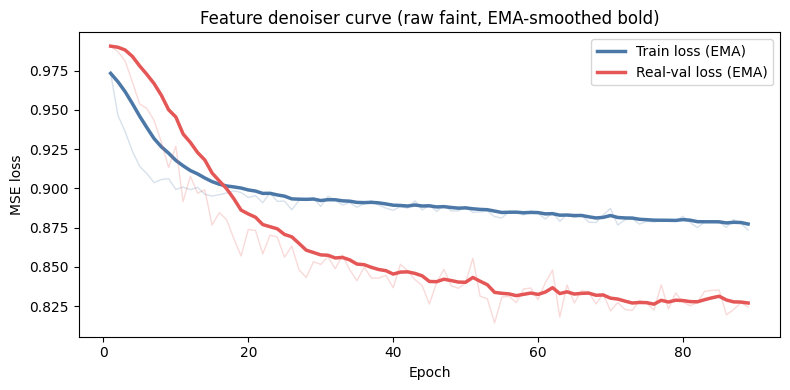

EMA smoothing uses alpha=0.20


In [14]:
print(f"\nBest real-validation denoiser loss: {best_val_loss:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
plot_raw_and_smooth(ax, train_history, label="Train loss", color="#4C78A8")
plot_raw_and_smooth(ax, val_history, label="Real-val loss", color="#E45756")
ax.set_title("Feature denoiser curve (raw faint, EMA-smoothed bold)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.tight_layout()
plt.show()

print(f"EMA smoothing uses alpha={PLOT_SMOOTH_ALPHA:.2f}")

In [16]:
# Synthetic Feature Generation

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

class_names = {0: "normal", 1: "pneumonia"}

N_SYNTH_PER_CLASS = 2000
GEN_BATCH_SIZE = 512

@torch.no_grad()
def sample_synthetic_features(
    num_samples,
    class_label,
    batch_size=GEN_BATCH_SIZE,
    cfg_scale=CFG_SCALE,
):
    ema_denoiser.eval()

    generated_batches = []
    remaining = num_samples
    progress = tqdm(total=num_samples, desc=f"Synth class {class_label}", dynamic_ncols=True)

    while remaining > 0:
        current_bs = min(batch_size, remaining)

        x_t = torch.randn(current_bs, FEATURE_DIM, device=device)
        c_cond = torch.full((current_bs,), class_label, dtype=torch.long, device=device)
        c_uncond = torch.full((current_bs,), UNCOND_CLASS, dtype=torch.long, device=device)

        for step in reversed(range(DIFF_STEPS)):
            t_frac = torch.full(
                (current_bs, 1),
                step / DIFF_STEPS,
                dtype=torch.float32,
                device=device,
            )

            eps_cond = ema_denoiser(x_t, t_frac, c_cond)
            eps_uncond = ema_denoiser(x_t, t_frac, c_uncond)
            eps = eps_uncond + cfg_scale * (eps_cond - eps_uncond)

            alpha_bar_t = alphas_cum[step]
            x0_pred = (x_t - torch.sqrt(1.0 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)

            if step > 0:
                alpha_bar_prev = alphas_cum[step - 1]
                x_t = torch.sqrt(alpha_bar_prev) * x0_pred + torch.sqrt(1.0 - alpha_bar_prev) * eps
            else:
                x_t = x0_pred

        generated_batches.append(x_t.detach().cpu().numpy().astype(np.float32))
        remaining -= current_bs
        progress.update(current_bs)

    progress.close()
    return np.vstack(generated_batches).astype(np.float32)

def median_heuristic_sigma(X, Y):
    joined = np.vstack([X, Y]).astype(np.float32)
    joined_t = torch.tensor(joined, dtype=torch.float32)
    if len(joined_t) > 400:
        idx = torch.randperm(len(joined_t))[:400]
        joined_t = joined_t[idx]
    dists = torch.pdist(joined_t)
    sigma = torch.median(dists).item() if len(dists) > 0 else 1.0
    return max(sigma, 1e-3)

def mmd_rbf(X, Y):
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=device)

    sigma = median_heuristic_sigma(X, Y)
    gamma = 1.0 / (2.0 * sigma * sigma)

    XX = torch.exp(-gamma * torch.cdist(X_t, X_t).pow(2)).mean()
    YY = torch.exp(-gamma * torch.cdist(Y_t, Y_t).pow(2)).mean()
    XY = torch.exp(-gamma * torch.cdist(X_t, Y_t).pow(2)).mean()

    return float((XX + YY - 2.0 * XY).item()), sigma

def covariance_gap(X, Y):
    cov_x = np.cov(X, rowvar=False)
    cov_y = np.cov(Y, rowvar=False)
    return float(np.linalg.norm(cov_x - cov_y, ord="fro") / X.shape[1])

In [17]:
print("Generating synthetic features")

synthetic_dataset = {}
for cls in [0, 1]:
    synthetic_dataset[cls] = sample_synthetic_features(
        num_samples=N_SYNTH_PER_CLASS,
        class_label=cls,
        batch_size=GEN_BATCH_SIZE,
        cfg_scale=CFG_SCALE,
    )
    print(f"  Class {cls} ({class_names[cls]}): shape={synthetic_dataset[cls].shape}")

Generating synthetic features


Synth class 0:   0%|          | 0/2000 [00:00<?, ?it/s]

  Class 0 (normal): shape=(2000, 128)


Synth class 1:   0%|          | 0/2000 [00:00<?, ?it/s]

  Class 1 (pneumonia): shape=(2000, 128)


Synthetic vs real-validation diagnostics
Class 0 (normal): n_eval=135, mean_gap=1.8435, cov_gap=0.1895, MMD=0.0099, sigma=16.4619
Class 1 (pneumonia): n_eval=300, mean_gap=0.9200, cov_gap=0.0818, MMD=0.0049, sigma=14.5711


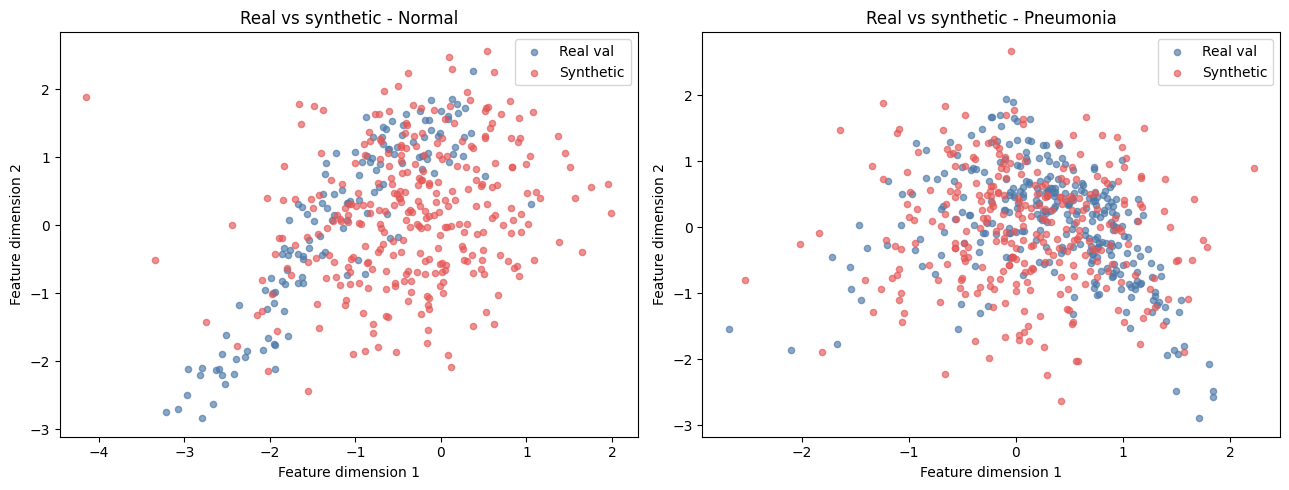


Synthetic training set ready
  X_syn shape: (4000, 128)
  y_syn shape: (4000,)
  normal=2000, pneumonia=2000


In [18]:
print("Synthetic vs real-validation diagnostics")

diagnostics = {}

for cls in [0, 1]:
    real_cls = X_val_features[y_val_raw == cls].astype(np.float32)
    synth_cls = synthetic_dataset[cls].astype(np.float32)

    n_eval = min(len(real_cls), len(synth_cls), 300)
    real_idx = np.random.choice(len(real_cls), size=n_eval, replace=False)
    synth_idx = np.random.choice(len(synth_cls), size=n_eval, replace=False)

    real_eval = real_cls[real_idx]
    synth_eval = synth_cls[synth_idx]

    mean_gap = float(np.linalg.norm(real_eval.mean(axis=0) - synth_eval.mean(axis=0)))
    cov_gap = covariance_gap(real_eval, synth_eval)
    mmd_value, sigma = mmd_rbf(real_eval, synth_eval)

    diagnostics[cls] = {
        "n_eval": n_eval,
        "mean_gap": mean_gap,
        "cov_gap": cov_gap,
        "mmd": mmd_value,
        "sigma": sigma,
    }

    print(
        f"Class {cls} ({class_names[cls]}): "
        f"n_eval={n_eval}, mean_gap={mean_gap:.4f}, cov_gap={cov_gap:.4f}, "
        f"MMD={mmd_value:.4f}, sigma={sigma:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cls, ax in zip([0, 1], axes):
    real_cls = X_val_features[y_val_raw == cls].astype(np.float32)
    synth_cls = synthetic_dataset[cls].astype(np.float32)

    real_n = min(len(real_cls), 300)
    synth_n = min(len(synth_cls), 300)

    real_idx = np.random.choice(len(real_cls), size=real_n, replace=False)
    synth_idx = np.random.choice(len(synth_cls), size=synth_n, replace=False)

    ax.scatter(
        real_cls[real_idx, 0],
        real_cls[real_idx, 1],
        s=20,
        alpha=0.65,
        color="#4C78A8",
        label="Real val",
    )
    ax.scatter(
        synth_cls[synth_idx, 0],
        synth_cls[synth_idx, 1],
        s=20,
        alpha=0.65,
        color="#E45756",
        label="Synthetic",
    )

    ax.set_title(f"Real vs synthetic - {class_names[cls].title()}")
    ax.set_xlabel("Feature dimension 1")
    ax.set_ylabel("Feature dimension 2")
    ax.legend()

plt.tight_layout()
plt.show()

X_syn = np.vstack([synthetic_dataset[0], synthetic_dataset[1]]).astype(np.float32)
y_syn = np.concatenate([
    np.zeros(len(synthetic_dataset[0]), dtype=np.int64),
    np.ones(len(synthetic_dataset[1]), dtype=np.int64),
])

print("\nSynthetic training set ready")
print(f"  X_syn shape: {X_syn.shape}")
print(f"  y_syn shape: {y_syn.shape}")
print(f"  normal={np.sum(y_syn == 0)}, pneumonia={np.sum(y_syn == 1)}")

In [19]:
# Synthetic-Only Downstream Classifier

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
)
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_cls_dataset = TensorDataset(
    torch.tensor(X_syn, dtype=torch.float32),
    torch.tensor(y_syn.astype(np.float32)).unsqueeze(1),
)

val_cls_dataset = TensorDataset(
    torch.tensor(X_val_features, dtype=torch.float32),
    torch.tensor(y_val_raw.astype(np.float32)).unsqueeze(1),
)

test_cls_dataset = TensorDataset(
    torch.tensor(X_test_features, dtype=torch.float32),
    torch.tensor(y_test_raw.astype(np.float32)).unsqueeze(1),
)

train_cls_loader = DataLoader(
    train_cls_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_cls_loader = DataLoader(
    val_cls_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_cls_loader = DataLoader(
    test_cls_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

class DiagnosticMLP(nn.Module):
    def __init__(self, input_dim=FEATURE_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)

classifier = DiagnosticMLP(input_dim=FEATURE_DIM).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(classifier.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=200,
    eta_min=1e-5,
)

MAX_EPOCHS = 200
PATIENCE = 25

@torch.no_grad()
def evaluate_classifier(model, loader):
    model.eval()

    total_loss = 0.0
    total_count = 0
    logits_all = []
    targets_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        batch_size = len(X_batch)
        total_loss += loss.item() * batch_size
        total_count += batch_size

        logits_all.append(logits.detach().cpu().numpy())
        targets_all.append(y_batch.detach().cpu().numpy())

    logits_all = np.vstack(logits_all).squeeze()
    targets_all = np.vstack(targets_all).squeeze().astype(int)
    probs_all = 1.0 / (1.0 + np.exp(-logits_all))

    avg_loss = total_loss / max(total_count, 1)
    auc = roc_auc_score(targets_all, probs_all)

    return {
        "loss": avg_loss,
        "auc": auc,
        "probs": probs_all,
        "targets": targets_all,
    }

def compute_metrics(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    auc = roc_auc_score(y_true, probs)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    bal_acc = 0.5 * (recall + specificity)

    return {
        "accuracy": acc,
        "auc": auc,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "balanced_accuracy": bal_acc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "preds": preds,
    }


In [21]:
# Train and Evaluate the Synthetic-Only Classifier
syn_best_state = None
syn_best_epoch = -1
syn_best_val_auc = -np.inf
syn_best_val_loss = np.inf
syn_patience_counter = 0

syn_train_loss_history = []
syn_val_loss_history = []
syn_val_auc_history = []

print("Training final classifier on SYNTHETIC features")

epoch_bar = tqdm(range(MAX_EPOCHS), desc="Synthetic classifier training", dynamic_ncols=True)

for epoch in epoch_bar:
    classifier.train()
    running_loss = 0.0
    sample_count = 0

    for X_batch, y_batch in train_cls_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = classifier(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = len(X_batch)
        running_loss += loss.item() * batch_size
        sample_count += batch_size

    scheduler.step()

    train_loss = running_loss / max(sample_count, 1)
    val_stats = evaluate_classifier(classifier, val_cls_loader)
    val_loss = val_stats["loss"]
    val_auc = val_stats["auc"]

    syn_train_loss_history.append(train_loss)
    syn_val_loss_history.append(val_loss)
    syn_val_auc_history.append(val_auc)

    improved = (val_auc > syn_best_val_auc + 1e-4) or (
        abs(val_auc - syn_best_val_auc) <= 1e-4 and val_loss < syn_best_val_loss
    )

    if improved:
        syn_best_state = {k: v.detach().cpu().clone() for k, v in classifier.state_dict().items()}
        syn_best_epoch = epoch + 1
        syn_best_val_auc = val_auc
        syn_best_val_loss = val_loss
        syn_patience_counter = 0
    else:
        syn_patience_counter += 1

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        auc=f"{val_auc:.4f}",
        best=f"{syn_best_val_auc:.4f}",
        patience=f"{syn_patience_counter}/{PATIENCE}",
    )

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:>3} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_auc={val_auc:.4f} | "
            f"best_val_auc={syn_best_val_auc:.4f}"
        )

    if syn_patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}")
        break

classifier.load_state_dict(syn_best_state)
classifier = classifier.to(device)
classifier.eval()

print(f"\nBest synthetic classifier epoch : {syn_best_epoch}")
print(f"Best synthetic validation AUC   : {syn_best_val_auc:.4f}")
print(f"Best synthetic validation loss  : {syn_best_val_loss:.4f}")

syn_val_stats = evaluate_classifier(classifier, val_cls_loader)
syn_val_probs = syn_val_stats["probs"]
syn_val_targets = syn_val_stats["targets"]

syn_threshold_grid = np.linspace(0.05, 0.95, 181)
syn_threshold_rows = []

for thr in syn_threshold_grid:
    metrics = compute_metrics(syn_val_targets, syn_val_probs, thr)
    syn_threshold_rows.append(
        {
            "threshold": thr,
            "f1": metrics["f1"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "recall": metrics["recall"],
            "specificity": metrics["specificity"],
        }
    )

syn_best_threshold_row = max(
    syn_threshold_rows,
    key=lambda row: (row["balanced_accuracy"], row["f1"])
)
syn_best_threshold = float(syn_best_threshold_row["threshold"])

print(f"\nChosen synthetic decision threshold : {syn_best_threshold:.3f}")
print(
    f"Validation @ threshold              : "
    f"bal_acc={syn_best_threshold_row['balanced_accuracy']:.4f}, "
    f"f1={syn_best_threshold_row['f1']:.4f}, "
    f"recall={syn_best_threshold_row['recall']:.4f}, "
    f"specificity={syn_best_threshold_row['specificity']:.4f}"
)

syn_test_stats = evaluate_classifier(classifier, test_cls_loader)
syn_test_probs = syn_test_stats["probs"]
syn_test_targets = syn_test_stats["targets"]
syn_test_metrics = compute_metrics(syn_test_targets, syn_test_probs, syn_best_threshold)

synthetic_summary = {
    "threshold": float(syn_best_threshold),
    "val_auc": float(syn_best_val_auc),
    "val_loss": float(syn_best_val_loss),
    "test_auc": float(syn_test_metrics["auc"]),
    "test_accuracy": float(syn_test_metrics["accuracy"]),
    "test_precision": float(syn_test_metrics["precision"]),
    "test_recall": float(syn_test_metrics["recall"]),
    "test_specificity": float(syn_test_metrics["specificity"]),
    "test_f1": float(syn_test_metrics["f1"]),
    "test_bal_acc": float(syn_test_metrics["balanced_accuracy"]),
}

print("\nFinal SYNTHETIC-trained test metrics on REAL test split")
print(f"Accuracy          : {syn_test_metrics['accuracy']:.4f}")
print(f"AUC-ROC           : {syn_test_metrics['auc']:.4f}")
print(f"Precision         : {syn_test_metrics['precision']:.4f}")
print(f"Recall            : {syn_test_metrics['recall']:.4f}")
print(f"Specificity       : {syn_test_metrics['specificity']:.4f}")
print(f"F1-score          : {syn_test_metrics['f1']:.4f}")
print(f"Balanced accuracy : {syn_test_metrics['balanced_accuracy']:.4f}")
print(
    f"Confusion matrix  : "
    f"TN={syn_test_metrics['tn']} FP={syn_test_metrics['fp']} "
    f"FN={syn_test_metrics['fn']} TP={syn_test_metrics['tp']}"
)

Training final classifier on SYNTHETIC features


Synthetic classifier training:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch   1 | train_loss=0.2448 | val_loss=0.4638 | val_auc=0.9060 | best_val_auc=0.9060
Epoch  10 | train_loss=0.1847 | val_loss=0.5310 | val_auc=0.8999 | best_val_auc=0.9060
Epoch  20 | train_loss=0.1552 | val_loss=0.5656 | val_auc=0.8973 | best_val_auc=0.9060

Early stopping triggered at epoch 26

Best synthetic classifier epoch : 1
Best synthetic validation AUC   : 0.9060
Best synthetic validation loss  : 0.4638

Chosen synthetic decision threshold : 0.450
Validation @ threshold              : bal_acc=0.8593, f1=0.8818, recall=0.8149, specificity=0.9037

Final SYNTHETIC-trained test metrics on REAL test split
Accuracy          : 0.7772
AUC-ROC           : 0.8376
Precision         : 0.8177
Recall            : 0.8282
Specificity       : 0.6923
F1-score          : 0.8229
Balanced accuracy : 0.7603
Confusion matrix  : TN=162 FP=72 FN=67 TP=323


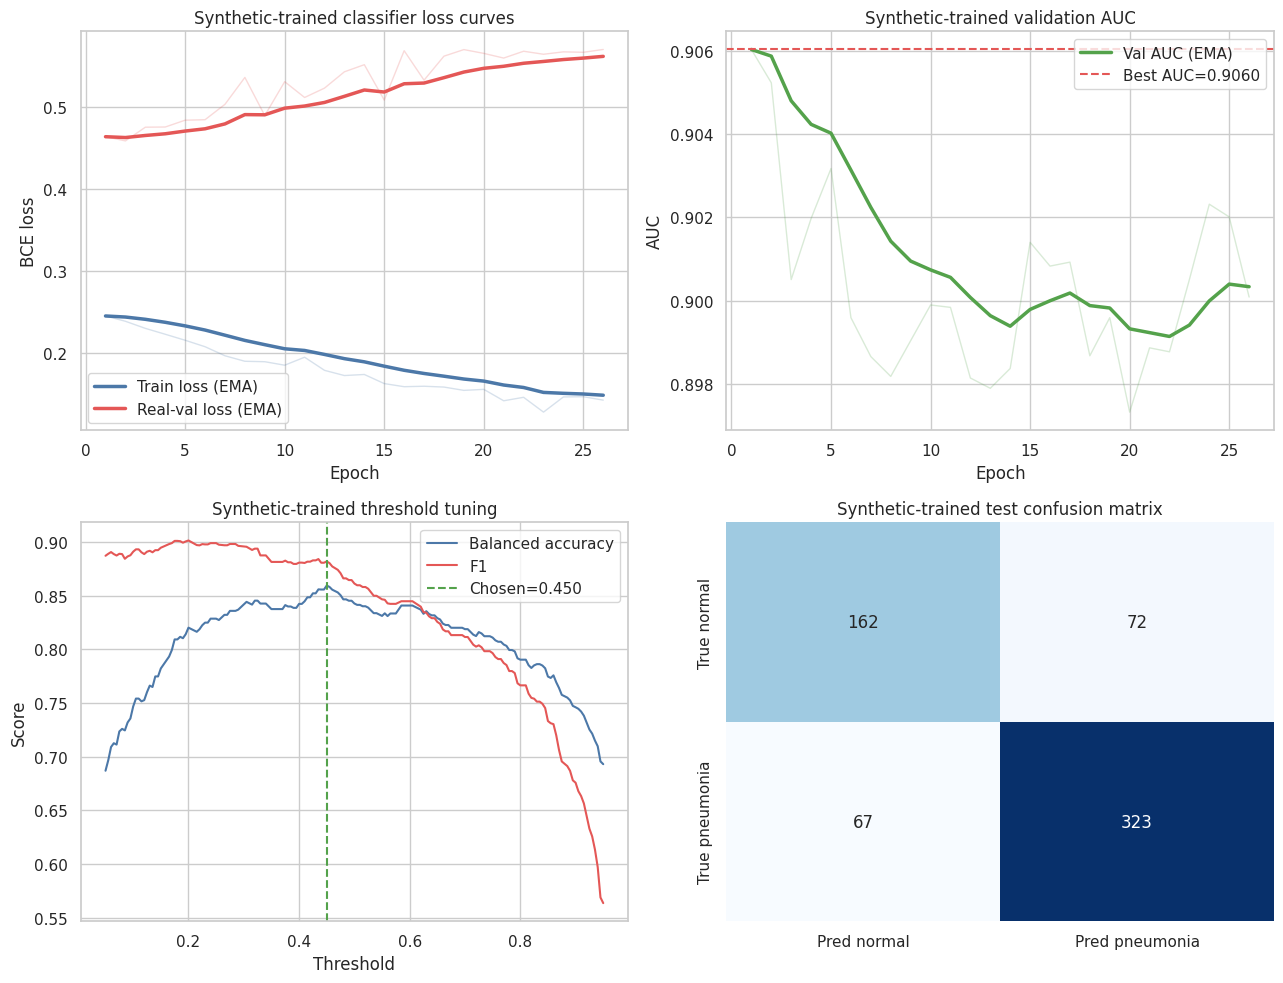

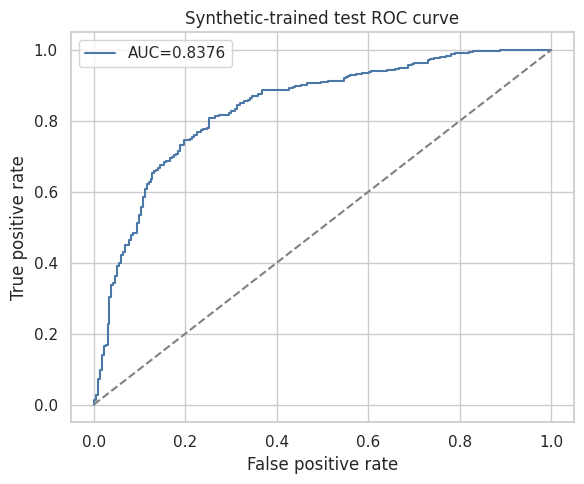

Visualization note: EMA smoothing uses alpha=0.20


In [22]:
# Synthetic-Only Test Result Plots

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

plot_raw_and_smooth(axes[0, 0], syn_train_loss_history, label="Train loss", color="#4C78A8")
plot_raw_and_smooth(axes[0, 0], syn_val_loss_history, label="Real-val loss", color="#E45756")
axes[0, 0].set_title("Synthetic-trained classifier loss curves")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE loss")
axes[0, 0].legend()

plot_raw_and_smooth(axes[0, 1], syn_val_auc_history, label="Val AUC", color="#54A24B")
axes[0, 1].axhline(
    syn_best_val_auc,
    color="#E45756",
    linestyle="--",
    label=f"Best AUC={syn_best_val_auc:.4f}",
)
axes[0, 1].set_title("Synthetic-trained validation AUC")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("AUC")
axes[0, 1].legend()

axes[1, 0].plot(
    [row["threshold"] for row in syn_threshold_rows],
    [row["balanced_accuracy"] for row in syn_threshold_rows],
    label="Balanced accuracy",
    color="#4C78A8",
)
axes[1, 0].plot(
    [row["threshold"] for row in syn_threshold_rows],
    [row["f1"] for row in syn_threshold_rows],
    label="F1",
    color="#E45756",
)
axes[1, 0].axvline(
    syn_best_threshold,
    color="#54A24B",
    linestyle="--",
    label=f"Chosen={syn_best_threshold:.3f}",
)
axes[1, 0].set_title("Synthetic-trained threshold tuning")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend()

syn_cm = np.array([
    [syn_test_metrics["tn"], syn_test_metrics["fp"]],
    [syn_test_metrics["fn"], syn_test_metrics["tp"]],
])
sns.heatmap(
    syn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[1, 1],
    xticklabels=["Pred normal", "Pred pneumonia"],
    yticklabels=["True normal", "True pneumonia"],
)
axes[1, 1].set_title("Synthetic-trained test confusion matrix")

plt.tight_layout()
plt.show()

syn_fpr, syn_tpr, _ = roc_curve(syn_test_targets, syn_test_probs)
plt.figure(figsize=(6, 5))
plt.plot(syn_fpr, syn_tpr, color="#4C78A8", label=f"AUC={syn_test_metrics['auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Synthetic-trained test ROC curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Visualization note: EMA smoothing uses alpha={PLOT_SMOOTH_ALPHA:.2f}")

In [23]:
# Real-Feature Ceiling Baseline Setup

real_train_dataset = TensorDataset(
    torch.tensor(X_train_features, dtype=torch.float32),
    torch.tensor(y_train_raw.astype(np.float32)).unsqueeze(1),
)

real_val_dataset = TensorDataset(
    torch.tensor(X_val_features, dtype=torch.float32),
    torch.tensor(y_val_raw.astype(np.float32)).unsqueeze(1),
)

real_test_dataset = TensorDataset(
    torch.tensor(X_test_features, dtype=torch.float32),
    torch.tensor(y_test_raw.astype(np.float32)).unsqueeze(1),
)

real_train_loader = DataLoader(
    real_train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

real_val_loader = DataLoader(
    real_val_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

real_test_loader = DataLoader(
    real_test_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

class DiagnosticMLPBaseline(nn.Module):
    def __init__(self, input_dim=FEATURE_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)

baseline_model = DiagnosticMLPBaseline(input_dim=FEATURE_DIM).to(device)
baseline_criterion = nn.BCEWithLogitsLoss()
baseline_optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=3e-4, weight_decay=1e-3)
baseline_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    baseline_optimizer,
    T_max=150,
    eta_min=1e-5,
)

BASELINE_MAX_EPOCHS = 150
BASELINE_PATIENCE = 20

@torch.no_grad()
def evaluate_baseline(model, loader):
    model.eval()

    total_loss = 0.0
    total_count = 0
    logits_all = []
    targets_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = baseline_criterion(logits, y_batch)

        batch_size = len(X_batch)
        total_loss += loss.item() * batch_size
        total_count += batch_size

        logits_all.append(logits.detach().cpu().numpy())
        targets_all.append(y_batch.detach().cpu().numpy())

    logits_all = np.vstack(logits_all).squeeze()
    targets_all = np.vstack(targets_all).squeeze().astype(int)
    probs_all = 1.0 / (1.0 + np.exp(-logits_all))

    avg_loss = total_loss / max(total_count, 1)
    auc = roc_auc_score(targets_all, probs_all)

    return {
        "loss": avg_loss,
        "auc": auc,
        "probs": probs_all,
        "targets": targets_all,
    }

In [24]:
# Train and Evaluate the Real-Feature Baseline

real_best_state = None
real_best_epoch = -1
real_best_val_auc = -np.inf
real_best_val_loss = np.inf
real_patience_counter = 0

real_train_loss_history = []
real_val_loss_history = []
real_val_auc_history = []

print("Training centralized REAL-feature baseline")

epoch_bar = tqdm(range(BASELINE_MAX_EPOCHS), desc="Real baseline training", dynamic_ncols=True)

for epoch in epoch_bar:
    baseline_model.train()
    running_loss = 0.0
    sample_count = 0

    for X_batch, y_batch in real_train_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        baseline_optimizer.zero_grad(set_to_none=True)
        logits = baseline_model(X_batch)
        loss = baseline_criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), max_norm=1.0)
        baseline_optimizer.step()

        batch_size = len(X_batch)
        running_loss += loss.item() * batch_size
        sample_count += batch_size

    baseline_scheduler.step()

    train_loss = running_loss / max(sample_count, 1)
    val_stats = evaluate_baseline(baseline_model, real_val_loader)
    val_loss = val_stats["loss"]
    val_auc = val_stats["auc"]

    real_train_loss_history.append(train_loss)
    real_val_loss_history.append(val_loss)
    real_val_auc_history.append(val_auc)

    improved = (val_auc > real_best_val_auc + 1e-4) or (
        abs(val_auc - real_best_val_auc) <= 1e-4 and val_loss < real_best_val_loss
    )

    if improved:
        real_best_state = {k: v.detach().cpu().clone() for k, v in baseline_model.state_dict().items()}
        real_best_epoch = epoch + 1
        real_best_val_auc = val_auc
        real_best_val_loss = val_loss
        real_patience_counter = 0
    else:
        real_patience_counter += 1

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        auc=f"{val_auc:.4f}",
        best=f"{real_best_val_auc:.4f}",
        patience=f"{real_patience_counter}/{BASELINE_PATIENCE}",
    )

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:>3} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_auc={val_auc:.4f} | "
            f"best_val_auc={real_best_val_auc:.4f}"
        )

    if real_patience_counter >= BASELINE_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}")
        break

baseline_model.load_state_dict(real_best_state)
baseline_model.eval()

print(f"\nBest real baseline epoch    : {real_best_epoch}")
print(f"Best real baseline val AUC  : {real_best_val_auc:.4f}")
print(f"Best real baseline val loss : {real_best_val_loss:.4f}")

real_val_stats = evaluate_baseline(baseline_model, real_val_loader)
real_val_probs = real_val_stats["probs"]
real_val_targets = real_val_stats["targets"]

real_threshold_grid = np.linspace(0.05, 0.95, 181)
real_threshold_rows = []

for thr in real_threshold_grid:
    metrics = compute_metrics(real_val_targets, real_val_probs, thr)
    real_threshold_rows.append(
        {
            "threshold": thr,
            "f1": metrics["f1"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "recall": metrics["recall"],
            "specificity": metrics["specificity"],
        }
    )

real_best_threshold_row = max(
    real_threshold_rows,
    key=lambda row: (row["balanced_accuracy"], row["f1"])
)
real_best_threshold = float(real_best_threshold_row["threshold"])

print(f"\nChosen real baseline threshold : {real_best_threshold:.3f}")
print(
    f"Validation @ threshold         : "
    f"bal_acc={real_best_threshold_row['balanced_accuracy']:.4f}, "
    f"f1={real_best_threshold_row['f1']:.4f}, "
    f"recall={real_best_threshold_row['recall']:.4f}, "
    f"specificity={real_best_threshold_row['specificity']:.4f}"
)

real_test_stats = evaluate_baseline(baseline_model, real_test_loader)
real_test_probs = real_test_stats["probs"]
real_test_targets = real_test_stats["targets"]
real_test_metrics = compute_metrics(real_test_targets, real_test_probs, real_best_threshold)

baseline_summary = {
    "threshold": float(real_best_threshold),
    "val_auc": float(real_best_val_auc),
    "val_loss": float(real_best_val_loss),
    "test_auc": float(real_test_metrics["auc"]),
    "test_accuracy": float(real_test_metrics["accuracy"]),
    "test_precision": float(real_test_metrics["precision"]),
    "test_recall": float(real_test_metrics["recall"]),
    "test_specificity": float(real_test_metrics["specificity"]),
    "test_f1": float(real_test_metrics["f1"]),
    "test_bal_acc": float(real_test_metrics["balanced_accuracy"]),
}

print("\nFinal REAL-feature baseline metrics on REAL test split")
print("-" * 72)
print(f"Accuracy          : {real_test_metrics['accuracy']:.4f}")
print(f"AUC-ROC           : {real_test_metrics['auc']:.4f}")
print(f"Precision         : {real_test_metrics['precision']:.4f}")
print(f"Recall            : {real_test_metrics['recall']:.4f}")
print(f"Specificity       : {real_test_metrics['specificity']:.4f}")
print(f"F1-score          : {real_test_metrics['f1']:.4f}")
print(f"Balanced accuracy : {real_test_metrics['balanced_accuracy']:.4f}")
print(
    f"Confusion matrix  : "
    f"TN={real_test_metrics['tn']} FP={real_test_metrics['fp']} "
    f"FN={real_test_metrics['fn']} TP={real_test_metrics['tp']}"
)

Training centralized REAL-feature baseline


Real baseline training:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch   1 | train_loss=0.5679 | val_loss=0.5074 | val_auc=0.8470 | best_val_auc=0.8470
Epoch  10 | train_loss=0.0785 | val_loss=0.1107 | val_auc=0.9910 | best_val_auc=0.9914
Epoch  20 | train_loss=0.0292 | val_loss=0.1108 | val_auc=0.9926 | best_val_auc=0.9926
Epoch  30 | train_loss=0.0122 | val_loss=0.1284 | val_auc=0.9923 | best_val_auc=0.9930
Epoch  40 | train_loss=0.0078 | val_loss=0.1326 | val_auc=0.9931 | best_val_auc=0.9932
Epoch  50 | train_loss=0.0043 | val_loss=0.1530 | val_auc=0.9928 | best_val_auc=0.9935
Epoch  60 | train_loss=0.0034 | val_loss=0.1664 | val_auc=0.9922 | best_val_auc=0.9935

Early stopping triggered at epoch 62

Best real baseline epoch    : 42
Best real baseline val AUC  : 0.9935
Best real baseline val loss : 0.1262

Chosen real baseline threshold : 0.950
Validation @ threshold         : bal_acc=0.9669, f1=0.9711, recall=0.9486, specificity=0.9852

Final REAL-feature baseline metrics on REAL test split
-------------------------------------------------------

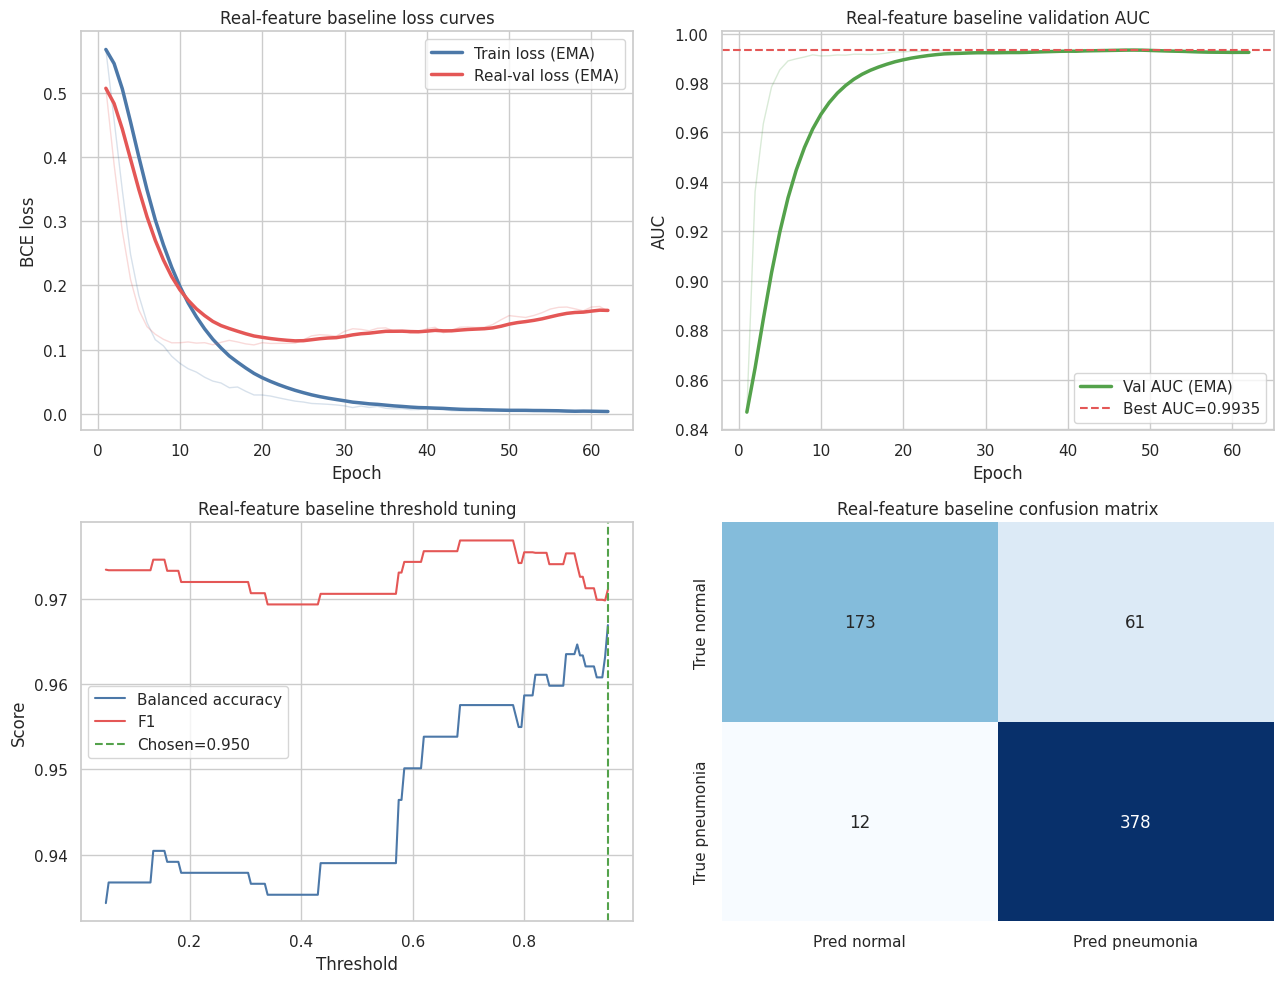

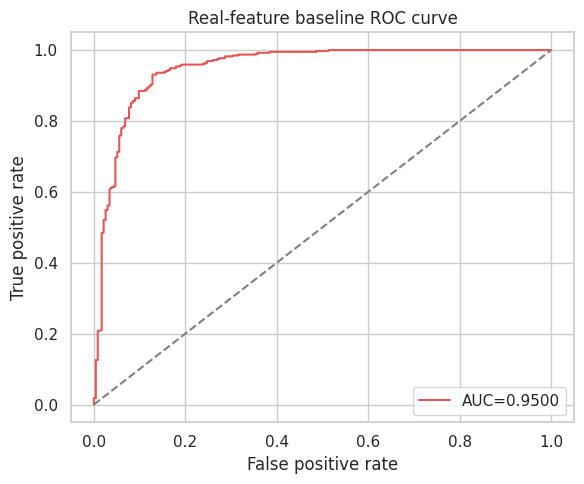

Visualization note: EMA smoothing uses alpha=0.20


In [25]:
# Real-Feature Baseline Test Result Plots

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

plot_raw_and_smooth(axes[0, 0], real_train_loss_history, label="Train loss", color="#4C78A8")
plot_raw_and_smooth(axes[0, 0], real_val_loss_history, label="Real-val loss", color="#E45756")
axes[0, 0].set_title("Real-feature baseline loss curves")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE loss")
axes[0, 0].legend()

plot_raw_and_smooth(axes[0, 1], real_val_auc_history, label="Val AUC", color="#54A24B")
axes[0, 1].axhline(
    real_best_val_auc,
    color="#E45756",
    linestyle="--",
    label=f"Best AUC={real_best_val_auc:.4f}",
)
axes[0, 1].set_title("Real-feature baseline validation AUC")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("AUC")
axes[0, 1].legend()

axes[1, 0].plot(
    [row["threshold"] for row in real_threshold_rows],
    [row["balanced_accuracy"] for row in real_threshold_rows],
    label="Balanced accuracy",
    color="#4C78A8",
)
axes[1, 0].plot(
    [row["threshold"] for row in real_threshold_rows],
    [row["f1"] for row in real_threshold_rows],
    label="F1",
    color="#E45756",
)
axes[1, 0].axvline(
    real_best_threshold,
    color="#54A24B",
    linestyle="--",
    label=f"Chosen={real_best_threshold:.3f}",
)
axes[1, 0].set_title("Real-feature baseline threshold tuning")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend()

real_cm = np.array([
    [real_test_metrics["tn"], real_test_metrics["fp"]],
    [real_test_metrics["fn"], real_test_metrics["tp"]],
])
sns.heatmap(
    real_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[1, 1],
    xticklabels=["Pred normal", "Pred pneumonia"],
    yticklabels=["True normal", "True pneumonia"],
)
axes[1, 1].set_title("Real-feature baseline confusion matrix")

plt.tight_layout()
plt.show()

real_fpr, real_tpr, _ = roc_curve(real_test_targets, real_test_probs)
plt.figure(figsize=(6, 5))
plt.plot(real_fpr, real_tpr, color="#E45756", label=f"AUC={real_test_metrics['auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Real-feature baseline ROC curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Visualization note: EMA smoothing uses alpha={PLOT_SMOOTH_ALPHA:.2f}")

In [28]:
# Final Comparison and Verdict

import pandas as pd
from IPython.display import display

comparison_rows = [
    ("Threshold", synthetic_summary["threshold"], baseline_summary["threshold"]),
    ("Val AUC", synthetic_summary["val_auc"], baseline_summary["val_auc"]),
    ("Test AUC", synthetic_summary["test_auc"], baseline_summary["test_auc"]),
    ("Accuracy", synthetic_summary["test_accuracy"], baseline_summary["test_accuracy"]),
    ("Precision", synthetic_summary["test_precision"], baseline_summary["test_precision"]),
    ("Recall", synthetic_summary["test_recall"], baseline_summary["test_recall"]),
    ("Specificity", synthetic_summary["test_specificity"], baseline_summary["test_specificity"]),
    ("F1", synthetic_summary["test_f1"], baseline_summary["test_f1"]),
    ("Balanced Acc", synthetic_summary["test_bal_acc"], baseline_summary["test_bal_acc"]),
]

summary_df = pd.DataFrame(
    comparison_rows,
    columns=["Metric", "Synthetic-only", "Real-feature baseline"]
)
summary_df["Gap (real - synthetic)"] = (
    summary_df["Real-feature baseline"] - summary_df["Synthetic-only"]
)
summary_df["Better setting"] = np.where(
    summary_df["Gap (real - synthetic)"] > 0,
    "Real baseline",
    np.where(summary_df["Gap (real - synthetic)"] < 0, "Synthetic-only", "Tie"),
)

print("Final comparison table")
display(
    summary_df.style
    .hide(axis="index")
    .format({
        "Synthetic-only": "{:.4f}",
        "Real-feature baseline": "{:.4f}",
        "Gap (real - synthetic)": "{:+.4f}",
    })
)

test_auc_gap = baseline_summary["test_auc"] - synthetic_summary["test_auc"]
val_auc_gap = baseline_summary["val_auc"] - synthetic_summary["val_auc"]
bal_acc_gap = baseline_summary["test_bal_acc"] - synthetic_summary["test_bal_acc"]

if test_auc_gap >= 0.05:
    verdict = "Methodology repair is done, but performance work is not done yet."
    diagnosis = "The synthetic branch is still the main bottleneck."
elif test_auc_gap >= 0.02:
    verdict = "Methodology repair is done, and the synthetic branch is moderately below the ceiling."
    diagnosis = "There is still meaningful room to improve synthesis fidelity."
else:
    verdict = "Methodology repair is done, and the synthetic branch is close to the ceiling."
    diagnosis = "Only incremental gains are likely from additional synthesis tuning."

calibration_warning = (
    synthetic_summary["threshold"] < 0.10 or baseline_summary["threshold"] > 0.90
)

print("\nWork-status verdict")
print(verdict)
print(diagnosis)
print(f"Validation AUC gap  : {val_auc_gap:+.4f}")
print(f"Test AUC gap        : {test_auc_gap:+.4f}")
print(f"Balanced acc gap    : {bal_acc_gap:+.4f}")

# if calibration_warning:
#     print("Calibration warning : threshold values are extreme, so probability calibration is still weak.")

Final comparison table


Metric,Synthetic-only,Real-feature baseline,Gap (real - synthetic),Better setting
Threshold,0.4500,0.9500,+0.5000,Real baseline
Val AUC,0.9060,0.9935,+0.0875,Real baseline
Test AUC,0.8376,0.9500,+0.1124,Real baseline
Accuracy,0.7772,0.8830,+0.1058,Real baseline
Precision,0.8177,0.8610,+0.0433,Real baseline
Recall,0.8282,0.9692,+0.1410,Real baseline
Specificity,0.6923,0.7393,+0.0470,Real baseline
F1,0.8229,0.9119,+0.0890,Real baseline
Balanced Acc,0.7603,0.8543,+0.0940,Real baseline



Work-status verdict
Methodology repair is done, but performance work is not done yet.
The synthetic branch is still the main bottleneck.
Validation AUC gap  : +0.0875
Test AUC gap        : +0.1124
Balanced acc gap    : +0.0940


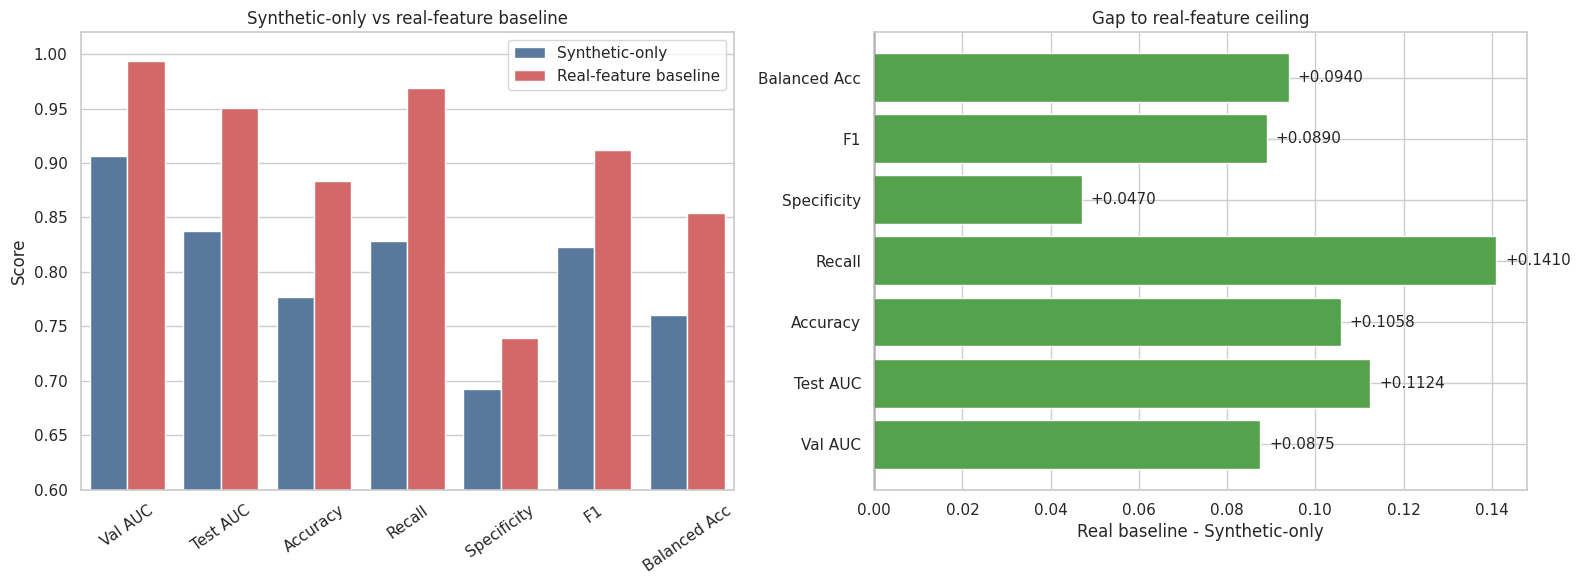

In [27]:
plot_metrics = ["Val AUC", "Test AUC", "Accuracy", "Recall", "Specificity", "F1", "Balanced Acc"]
plot_df = summary_df[summary_df["Metric"].isin(plot_metrics)].copy()

melted = plot_df.melt(
    id_vars="Metric",
    value_vars=["Synthetic-only", "Real-feature baseline"],
    var_name="Setting",
    value_name="Score",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=melted,
    x="Metric",
    y="Score",
    hue="Setting",
    palette=["#4C78A8", "#E45756"],
    ax=axes[0],
)
axes[0].set_title("Synthetic-only vs real-feature baseline")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.60, 1.02)
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="")

gap_colors = ["#54A24B" if gap >= 0 else "#E45756" for gap in plot_df["Gap (real - synthetic)"]]
axes[1].barh(plot_df["Metric"], plot_df["Gap (real - synthetic)"], color=gap_colors)
axes[1].axvline(0.0, color="black", linewidth=1)
axes[1].set_title("Gap to real-feature ceiling")
axes[1].set_xlabel("Real baseline - Synthetic-only")
axes[1].set_ylabel("")

for idx, value in enumerate(plot_df["Gap (real - synthetic)"]):
    x_text = value + 0.002 if value >= 0 else value - 0.002
    ha = "left" if value >= 0 else "right"
    axes[1].text(x_text, idx, f"{value:+.4f}", va="center", ha=ha, fontsize=11)

plt.tight_layout()
plt.show()